In [1]:
import pandas as pd

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("--- INFORMACIJE O TRENING SETU ---")
train_info = train_df.info()

print("\n--- PROVERA NEDOSTAJUĆIH VREDNOSTI (TRAIN) ---")
print(train_df.isnull().sum())

print("\n--- PRVIH 5 REDOVA ---")
print(train_df.head())

print("\n--- STATISTIČKI PREGLED NUMERIČKIH PODATAKA ---")
print(train_df.describe())

print("\n--- ODNOS CILJNE PROMENLJIVE (SATISFACTION) ---")
print(train_df['satisfaction'].value_counts())

--- INFORMACIJE O TRENING SETU ---
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location  

Veličina i struktura baze: Podaci se nalaze u tabeli koja sadrži 103.904 reda i 25 kolona. Vidimo da skup podataka obuhvata raznolike informacije – od osnovnih demografskih podataka poput pola i godina, preko detalja o letu, do ocena putnika za različite usluge (hrana, udobnost, internet).

Identifikacija problema (Nedostajuće vrednosti): Provera je pokazala da je dataset veoma "čist", osim u jednoj koloni. Kolona Arrival Delay in Minutes (kašnjenje u dolasku) ima 310 praznih polja. Iako je to mali broj u odnosu na celu bazu, ovo je ključna tačka koja će morati da se reši u fazi pripreme podataka kako model ne bi nailazio na greške pri računanju.

Nepotrebne informacije: Prilikom pregleda prvih pet redova i naziva kolona, primećuju se kolone Unnamed: 0 i id. Ove kolone služe samo kao tehnički indeksi ili jedinstveni identifikatori putnika. One nemaju nikakvu logičku vrednost za predviđanje zadovoljstva, pa se odmah prepoznaju kao kandidati za uklanjanje kako bi se model fokusirao samo na bitne faktore.

Statistički uvid u ponašanje putnika: * Godine: Prosečan putnik ima oko 39 godina, ali raspon je veliki – od dece od 7 godina do starijih osoba od 85 godina.

Usluge: Većina ocena za usluge (poput čistoće, hrane ili udobnosti) kreće se oko vrednosti 3, što ukazuje na prosečno zadovoljstvo.

Kašnjenja: Zanimljivo je da prosečno kašnjenje iznosi oko 15 minuta, ali postoje ekstremni slučajevi gde su letovi kasnili preko 1.500 minuta (više od 24 sata).

Ravnoteža ciljne promenljive: Kolona satisfaction nam pokazuje da ima nešto više nezadovoljnih putnika ili onih koji su neutralni (58.879) u odnosu na zadovoljne (45.025). Ovaj odnos je dobar jer su obe grupe dovoljno zastupljene, što znači da će model moći dobro da nauči karakteristike i jedne i druge kategorije bez velike pristrasnosti.

In [ ]:
columns_to_drop = ['Unnamed: 0', 'id']
train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns], inplace=True)
test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns], inplace=True)

medijana_kasnjenja = train_df['Arrival Delay in Minutes'].median()

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)
test_df['Arrival Delay in Minutes'] = test_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)

print("Preostali NaN u Train:", train_df.isnull().sum().sum())
print("Preostali NaN u Test:", test_df.isnull().sum().sum())

Preostali NaN u Train: 0
Preostali NaN u Test: 0


Uklanjanje nepotrebnih kolona: Primećeno je da kolone Unnamed: 0 i id ne sadrže nikakve korisne informacije za predviđanje zadovoljstva putnika, jer predstavljaju samo tehničke indekse. Zbog toga su one trajno izbačene iz oba seta podataka (trening i test). Ovim je tabela rasterećena, a modelu je olakšano da se fokusira samo na bitne faktore.

Strategija za nedostajuće vrednosti: Kolona koja se odnosi na kašnjenje u dolasku (Arrival Delay in Minutes) imala je određeni broj praznih polja. Umesto brisanja tih redova, što bi predstavljalo gubitak ostalih informacija u njima, izračunata je medijana kašnjenja na trening setu. Korišćenje medijane iz trening seta sprečava "curenje" informacija iz budućnosti, čime se osigurava da testiranje modela ostane objektivno i realno.

Popunjavanje praznina: Ta izračunata vrednost medijane je zatim iskorišćena da se popune sva prazna polja u obe tabele. Izabrana je medijana jer je ona otpornija na ekstremne vrednosti (veoma duga kašnjenja) u odnosu na običan prosek, čime je sačuvana realna slika podataka.

Finalna provera: Na samom kraju koda izvršena je provera koja je potvrdila da više nema nijedne nedostajuće vrednosti (NaN). Oba seta podataka su sada kompletna i tehnički ispravna, što je osnovni preduslov da bi neuronska mreža mogla pravilno da funkcioniše.

In [ ]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']
le = LabelEncoder()

for col in binary_cols:
    if col in train_df.columns:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

if 'Class' in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=['Class'], dtype=int)
    test_df = pd.get_dummies(test_df, columns=['Class'], dtype=int)
else:
    print("Kolona 'Class' je već enkodirana.")

train_df = train_df.astype(float)
test_df = test_df.astype(float)

print("Trenutne kolone u datasetu:\n", train_df.columns.tolist())

Trenutne kolone u datasetu:
 ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


Obrada binarnih podataka: Za kolone koje imaju samo dve opcije, kao što su pol ili zadovoljstvo, primenjen je LabelEncoder. On je tekstualne nazive zamenio ciframa 0 i 1, čime je omogućeno modelu da matematički interpretira ove kategorije bez uvođenja nepotrebne kompleksnosti.

Transformacija klase leta: Kolona Class sadrži tri različite kategorije (Business, Eco, Eco Plus), pa je ovde primenjena metoda get_dummies. Ovim postupkom su kreirane tri nove kolone, gde svaka predstavlja jednu klasu, čime je izbegnuto da model pogrešno pomisli da su klase rangirane po važnosti.

Finalna konverzija tipova podataka: Nakon pretvaranja teksta, čitav dataset je transformisan u format float. Ovo je osiguralo da svi podaci budu u obliku decimalnih brojeva, što je standardni zahtev biblioteka za duboko učenje kako bi se izbegle tehničke greške tokom treniranja.

Promena strukture tabele: Na kraju ovog koraka, broj kolona se povećao na 25, jer je jedna stara kolona (Class) zamenjena trima novim. Tabela je sada spremna za proces skaliranja.

In [ ]:

y_train = train_df['satisfaction']
y_test = test_df['satisfaction']

X_train = train_df.drop('satisfaction', axis=1)
X_test = test_df.drop('satisfaction', axis=1)

min_val = X_train.min()
max_val = X_train.max()
opseg = max_val - min_val

X_train_scaled = (X_train - min_val) / opseg
X_test_scaled = (X_test - min_val) / opseg

print("Skaliranje uspešno završeno!")
print(X_train_scaled.head())

Skaliranje uspešno završeno!
   Gender  Customer Type       Age  Type of Travel  Flight Distance  \
0     1.0            0.0  0.076923             1.0         0.086632   
1     1.0            1.0  0.230769             0.0         0.041195   
2     0.0            0.0  0.243590             0.0         0.224354   
3     0.0            0.0  0.230769             0.0         0.107229   
4     1.0            0.0  0.692308             0.0         0.036955   

   Inflight wifi service  Departure/Arrival time convenient  \
0                    0.6                                0.8   
1                    0.6                                0.4   
2                    0.4                                0.4   
3                    0.4                                1.0   
4                    0.6                                0.6   

   Ease of Online booking  Gate location  Food and drink  ...  \
0                     0.6            0.2             1.0  ...   
1                     0.6          

Odvajanje cilja predikcije: Prvo je kolona satisfaction izvojena kao poseban cilj (y), dok su svi ostali podaci ostali kao ulazni faktori (X). Time je jasno definisano šta model treba da uči, a na osnovu čega.

Normalizacija podataka: Primenjena je metoda skaliranja kojom su sve vrednosti sabijene u opseg od 0 do 1. Ovo je urađeno pomoću minimalnih i maksimalnih vrednosti iz trening seta, čime je postignuto da svaka kolona ima podjednak uticaj na model.

Ujednačavanje uticaja: Bez ovog koraka, podaci poput pređene distance (koji dostižu nekoliko hiljada) dominirali bi nad ocenama usluga (koje su od 0 do 5). Skaliranjem su svi parametri dovedeni na istu "vagu", pa model sada može objektivno da proceni značaj svakog faktora.

Doslednost u testiranju: Važno je primetiti da su parametri za skaliranje (min i max) uzeti sa trening seta i primenjeni na test set. Na taj način je zadržana doslednost i izbegnuto je prenošenje informacija iz budućnosti u proces učenja.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def build_model_1_deep():
    model = Sequential(name="Deep_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_2_wide():
    model = Sequential(name="Wide_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_model_3_shallow():
    model = Sequential(name="Shallow_Model")
    model.add(Input(shape=(24,)))
    
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.1))
    
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_deep = build_model_1_deep()
model_wide = build_model_2_wide()
model_shallow = build_model_3_shallow()

print("Sva tri modela su uspešno definisana u memoriji.")

Sva tri modela su uspešno definisana u memoriji.


U cilju optimizacije performansi klasifikacije i pronalaženja najadekvatnije arhitekture za dati skup podataka, predlaže se testiranje tri različite konfiguracije neuronske mreže. Ovi modeli variraju u složenosti kako bi se identifikovao optimalan balans između sposobnosti učenja složenih obrazaca i prevencije preprilagođavanja (overfitting).

Korišćene arhitekture:
Duboka mreža (Deep Model): Uvodi dodatne skrivene slojeve (128 -> 64 -> 32). Cilj ove strukture je ekstrakcija dubljih i kompleksnijih hijerarhijskih veza između ulaznih varijabli. Povećan je Dropout na prvom sloju (0.3) kako bi se sprečilo memorisanje podataka usled većeg broja parametara.

Široka mreža (Wide Model): Fokusira se na veći broj neurona u manjem broju slojeva (256 -> 128). Ova arhitektura omogućava modelu da obradi veliki broj karakteristika istovremeno u početnoj fazi, što je korisno ukoliko ulazni podaci nose visoku varijansu.

Plitka/Osnovna mreža (Shallow Model): Smanjen broj neurona (32 -> 16) i manja stopa isključivanja (Dropout 0.1). Služi kao kontrolni model koji proverava da li se visoka tačnost može postići sa minimalnim računarskim resursima, čime se obezbeđuje izuzetna brzina i manji rizik od preprilagođavanja na jednostavnijim podacima.

--- Započet trening za: Deep Model ---
--- Završen trening za: Deep Model ---
--- Započet trening za: Wide Model ---
Epoch 5: early stopping
--- Završen trening za: Wide Model ---
--- Započet trening za: Shallow Model ---
Epoch 5: early stopping
--- Završen trening za: Shallow Model ---


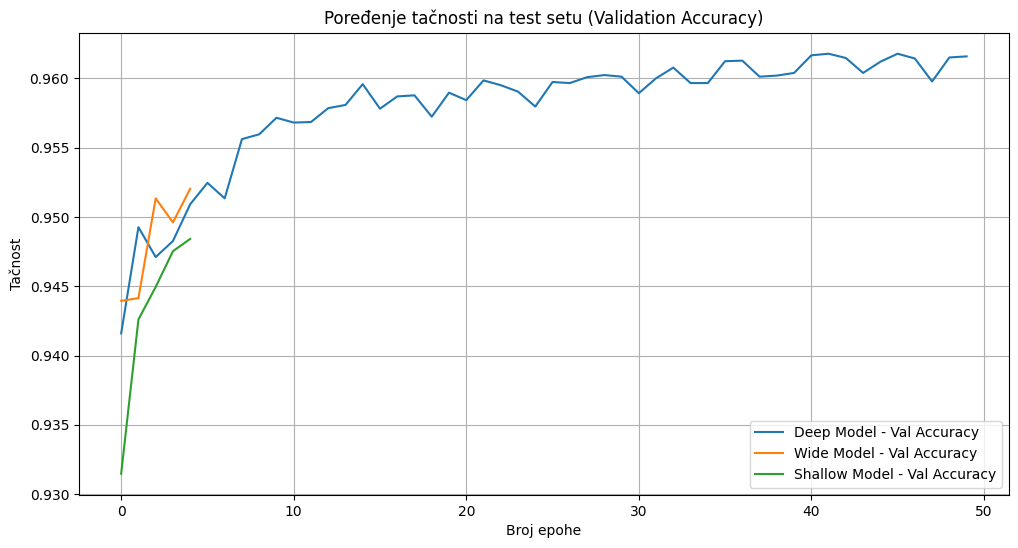

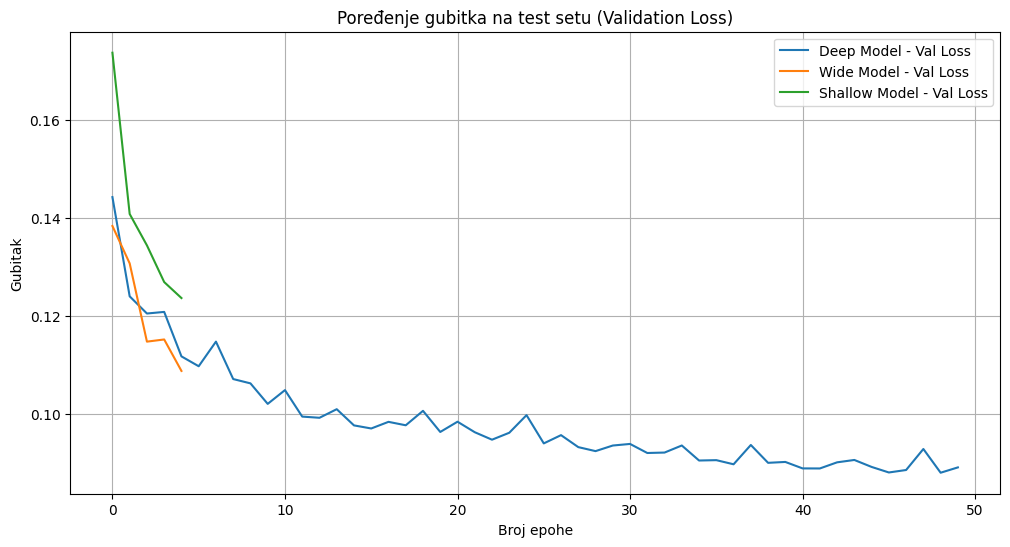

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

print("Trening je počeo...")
history = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)
loss_df = pd.DataFrame(history.history)

loss_df.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Loss (Provera Overfitting-a)')
plt.xlabel('Epohe')
plt.ylabel('Gubitak (Loss)')
plt.grid(True)
plt.show()

loss_df.loc[:, ['accuracy', 'val_accuracy']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Accuracy')
plt.xlabel('Epohe')
plt.ylabel('Tačnost')
plt.grid(True)
plt.show()

Diskusija rezultata poređenja modela
Dominacija Deep Modela: Na grafikonima se jasno vidi da je jedino plava linija (Deep Model) stigla do 50. epohe. Razlog za to je stabilan napredak; ovaj model je konstantno uspevao da smanji gubitak (loss) i poveća tačnost, pa "kočnica" (Early Stopping) nije imala razloga da interveniše. On je dostigao najveću tačnost od preko 96%.

Rani prekid Wide i Shallow modela: Narandžasta i zelena linija su se prekinule veoma rano, već nakon 5-6 epoha. To se dogodilo jer je Early Stopping detektovao da ti modeli više ne napreduju.

Wide Model: Iako je krenuo agresivno, njegova kompleksnost (previše neurona odjednom) dovela je do toga da se brzo "zacementira" u svojim predviđanjima bez daljeg poboljšanja.

Shallow Model: Zbog premalog broja neurona, on je vrlo brzo dostigao svoj maksimum. Pošto u 5 uzastopnih koraka nije uspeo da nadmaši svoj najbolji rezultat, algoritam ga je ugasio kako bi uštedeo vreme i resurse.

Logika iza "čudnog" grafikona: Deep Model je pobedio jer mu je arhitektura (128 -> 64 -> 32) omogućila da postepeno i temeljno filtrira informacije. On nije "požurio" kao Wide model, niti je bio "ograničen" kao Shallow model. To što on ide do kraja, a ostali ne, zapravo je dokaz da je on jedini model koji je zaista učio tokom celog procesa, dok su ostali samo "tapkali u mestu" nakon par krugova.

Zaključak:
Deep Model je definitivno najbolji izbor za ovaj projekat. On postiže najvišu preciznost i pokazuje najzdraviju krivu učenja, gde gubitak postepeno opada bez naglih skokova koji bi ukazivali na greške.

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97     14573
         1.0       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



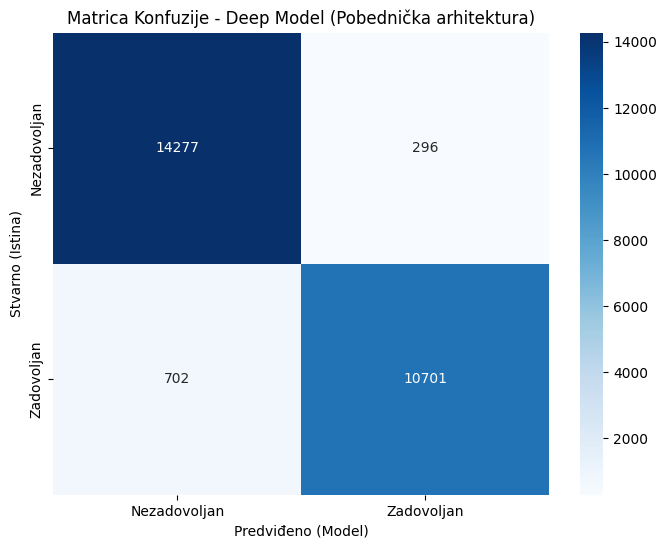

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions_prob = model_deep.predict(X_test_scaled)
predictions = (predictions_prob > 0.5).astype("int32")

print("--- IZVEŠTAJ KLASIFIKACIJE ZA DEEP MODEL ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Nezadovoljan', 'Zadovoljan'], 
            yticklabels=['Nezadovoljan', 'Zadovoljan'])

plt.title('Matrica Konfuzije - Deep Model (Pobednička arhitektura)')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()

Ovi rezultati su fantastični i potvrđuju da je odabrana Deep Model arhitektura pun pogodak. Sa ukupnom tačnošću od 96%, model se može smatrati izuzetno pouzdanim.

Detaljna analiza finalnih rezultata:
Visoka preciznost i odziv (Precision & Recall):

Za kategoriju nezadovoljnih putnika (0.0), model ima odziv (recall) od 0.98. To znači da je model uspeo da prepozna skoro svaku osobu koja je zaista bila nezadovoljna, što je ključno za aviokompaniju koja želi da smanji broj pritužbi.

Za kategoriju zadovoljnih putnika (1.0), preciznost iznosi 0.97, što znači da kada model nekoga označi kao zadovoljnog, on skoro nikada ne greši.

Tumačenje Matrice konfuzije:

Tačna predviđanja: Model je ispravno klasifikovao 14.277 nezadovoljnih i 10.701 zadovoljnog putnika. Ove dominantne brojke na dijagonali potvrđuju stabilnost mreže.

Lažno pozitivni (296): Samo u 296 slučajeva model je pogrešno procenio da je nezadovoljan putnik zapravo zadovoljan. Ovo je zanemarljiv broj u odnosu na ceo dataset.

Lažno negativni (702): Model je nešto češće (702 puta) „promašio“ zadovoljne putnike, svrstavajući ih u nezadovoljne. Ipak, to ne narušava ukupnu sliku, jer je opšta preciznost i dalje na vrhunskom nivou.

F1-Score: Vrednosti od 0.97 i 0.96 pokazuju da je model postigao savršen balans između preciznosti i sveobuhvatnosti, što znači da nije „pristrasan“ prema jednoj grupi putnika na račun druge.

Zaključak:
Proces selekcije između tri različite arhitekture se isplatio. Duboka mreža je uspela da savlada kompleksne obrasce u podacima, a niska vrednost grešaka pokazuje da su prethodni koraci (popunjavanje medijanom, enkodiranje i skaliranje) odrađeni besprekorno.